### Cлужебные ячейки

In [1]:
!pip install nltk spacy tqdm "pydantic<2.0.0" -q


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [ ]:
import os
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import requests
import spacy
from nltk.stem.porter import PorterStemmer
from nltk.util import bigrams as make_bigrams
from tqdm.notebook import tqdm

from transformers import BertTokenizer

nltk.download('punkt', quiet=True)
plt.rcParams['figure.dpi'] = 120

Unknown instance spec: Please select VM configuration

### Обработка данных

Clone the wikIR repository. Follow the repository README to build the `en1k` subset (run `wikIR_builder.py` with the appropriate config). After building, set `DOCS_PATH` to the generated `documents.csv`.

In [3]:
DOCS_PATH = '../datasets/wikIR1k/documents.csv'

In [4]:
# print(os.getcwd())

In [5]:
docs_df = pd.read_csv(DOCS_PATH)
print(f"Shape: {docs_df.shape}")
print(f"Columns: {list(docs_df.columns)}")
docs_df.head(3)

Shape: (369721, 2)
Columns: ['id_right', 'text_right']


,id_right,text_right
0,1781133,it was used in landing craft during world war ...
1,2426736,after rejecting an offer from cambridge univer...
2,2224122,mat zan coached kuala lumpur fa in 1999 and wo...


In [6]:
text_col = "text_right"
texts = docs_df[text_col].fillna('').astype(str).tolist()
len(texts)

369721

Всего в коллекции 369721 документов

### Токенизация WikIR

Согласно описанию датасета WikIR, коллекция предварительно очищена, токенизирована, приведена к нижнему регистру.
Токены разделены пробелом в исходном тексте. Заметно, что некоторые токены обрабатываются очень долго.

In [7]:
tokenized = [text.split() for text in tqdm(texts)]

  0%|          | 0/369721 [00:00<?, ?it/s]

In [8]:
all_tokens = []

all_tokens = [token for doc in tokenized for token in doc]

unique_tokens = set(all_tokens)

In [9]:
all_tokens[:10]

['it', 'was', 'used', 'in', 'landing', 'craft', 'during', 'world', 'war', 'ii']

---
## task 1. Provide basic collection stats (20)

In [10]:
n = len(tokenized)
n_words = len(all_tokens)
n_unique = len(unique_tokens)

basic_stats = {
    'Документов': n,
    'Всего слов в коллекции': n_words,
    'Средняя длина одного документа, слов:': round(n_words / n, 3),
    'Уникальных слов': n_unique,
    'Средняя длина одного слова': round(sum(len(w) for w in all_tokens) / n_words, 3),
    'Средняя длина уникального слова': round(sum(len(w) for w in unique_tokens) / n_unique, 3),
}

basic_stats

{'Документы': 369721,
 'Всего слов в коллекции': 73093729,
 'Средняя длина одного документа, слов:': 197.7,
 'Уникальных слов': 794568,
 'Средняя длина одного слова': 4.795,
 'Средняя длина уникального слова': 7.714}

---

## task 2. Build a frequency list (20)

### Стопслова

Fetch the English stopword list from the Sebleier gist (the NLTK English stopword list, 179 words). GitHub redirects the raw URL to the latest file revision.

In [11]:
raw_url = 'https://gist.githubusercontent.com/sebleier/554280/raw/'
response = requests.get(raw_url, allow_redirects=True)
stopwords = set(response.text.strip().split('\n'))
len(stopwords)

127

### Строим график частотности

In [12]:
freq_counter = Counter(all_tokens)
freq_list = freq_counter.most_common()

print(f"{'Rank':<6} {'Word':<22} {'Count':>10}  In stoplist")
print('-' * 55)
for rank, (word, count) in enumerate(freq_list[:30], 1):
    tag = 'yes' if word in stopwords else 'no'
    print(f"{rank:<6} {word:<22} {count:>10,}  {tag}")

Rank   Word                        Count  In stoplist
-------------------------------------------------------
1      the                     5,311,943  yes
2      of                      2,532,382  yes
3      in                      2,355,417  yes
4      and                     2,231,007  yes
5      a                       1,557,760  yes
6      to                      1,407,261  yes
7      was                     1,078,183  yes
8      he                        685,303  yes
9      is                        676,829  yes
10     as                        661,622  yes
11     for                       616,110  yes
12     on                        610,583  yes
13     with                      535,843  yes
14     by                        526,627  yes
15     s                         497,472  yes
16     at                        482,839  yes
17     his                       440,633  yes
18     from                      432,326  yes
19     it                        398,308  yes
20     that     

In [57]:
print(f"Guys not from stop-list")
print(f"{'Rank':<6} {'Word':<22} {'Count':>10}")
print('-' * 55)
cnt: int = 0
for rank, (word, count) in enumerate(freq_list, 1):
    if word not in stopwords:
        print(f"{rank:<6} {word:<22} {count:>10,}")
        cnt += 1
        if cnt == 30:
            break

Guys not from stop-list
Rank   Word                        Count
-------------------------------------------------------
23     first                     217,204
27     also                      186,055
32     one                       157,573
37     new                       139,850
38     two                       136,427
42     school                    119,897
44     university                107,386
50     time                       95,373
54     1                          89,967
55     years                      88,565
56     year                       85,032
59     later                      80,738
60     became                     80,151
61     city                       77,682
63     world                      77,013
64     three                      76,155
66     known                      73,969
69     state                      70,280
71     national                   69,849
72     part                       69,635
73     united                     68,263
74     2          

### Stopword Analysis

In [44]:
total_sw_occ = sum(freq_counter[w] for w in stopwords if w in freq_counter)
top30 = [w for w, _ in freq_list[:30]]
not_in_sw = [w for w in top30 if w not in stopwords]

print(f"Стоп-слов в тексте: {total_sw_occ:,}")
print(f"Процент от текста: {total_sw_occ / n_words * 100:.1f}%")
print(f"Норм.слова, которые попали в ТОП-30: {not_in_sw}")

Стоп-слов в тексте: 29,387,785
Процент от текста: 40.2%
Норм.слова, которые попали в ТОП-30: ['first', 'also']


### Закон Ципфа

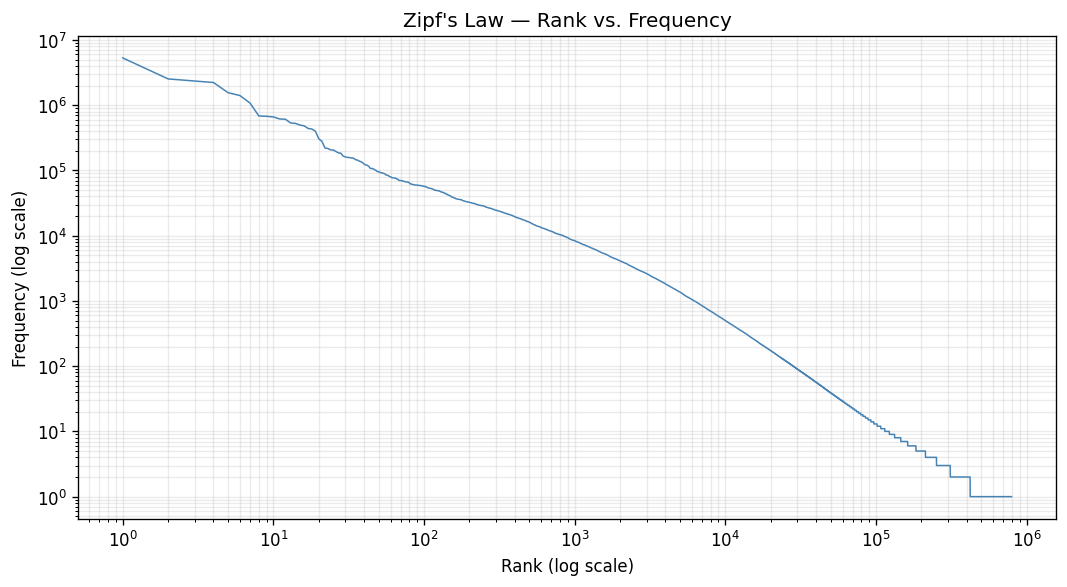

In [14]:
frequencies = np.array([count for _, count in freq_list])
ranks = np.arange(1, len(frequencies) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(ranks, frequencies, linewidth=0.9, color='steelblue')
ax.set_xlabel('Rank (log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title("Zipf's Law — Rank vs. Frequency")
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.show()

### Закон Хипса

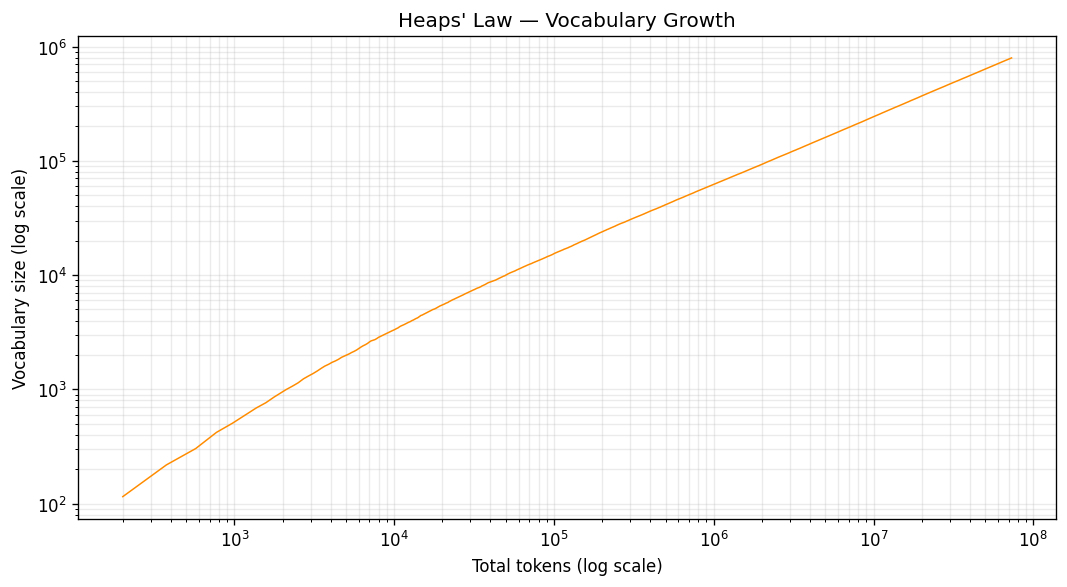

In [15]:
vocab_heap = set()
vocab_sizes = []
token_counts_heap = []
running_total = 0

for doc_tokens in tqdm(tokenized):
    for token in tqdm(doc_tokens):
        vocab_heap.add(token)
        running_total += 1
    vocab_sizes.append(len(vocab_heap))
    token_counts_heap.append(running_total)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(token_counts_heap, vocab_sizes, linewidth=0.9, color='darkorange')
ax.set_xlabel('Total tokens (log scale)')
ax.set_ylabel('Vocabulary size (log scale)')
ax.set_title("Heaps' Law")
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.show()

---

## Task 3. Build a frequency list of word bigrams (15)

In [16]:
bigram_counter = Counter()
for doc_tokens in tqdm(tokenized):
    bigram_counter.update(make_bigrams(doc_tokens))

print(f"Unique bigrams: {len(bigram_counter):,}")

  0%|          | 0/369721 [00:00<?, ?it/s]

Unique bigrams: 12,993,004


In [70]:
print(f"{'Bigram':<32} {'Count':>8} со смыслом?")
print('-' * 55)
for bigram, count in bigram_counter.most_common(31):
    w1, w2 = bigram
    is_content = (
        w1 not in stopwords and w2 not in stopwords
        and w1.isalpha() and w2.isalpha()
    )
    marker = 'да' if is_content else 'нет'
    pair = f"{w1} {w2}"
    print(f"{pair:<32} {count:>8,}  {marker}")

Bigram                              Count со смыслом?
-------------------------------------------------------
of the                            768,320  нет
in the                            546,863  нет
to the                            256,451  нет
at the                            201,351  нет
and the                           170,394  нет
on the                            169,708  нет
he was                            163,554  нет
as a                              163,073  нет
for the                           159,502  нет
by the                            130,810  нет
with the                          120,118  нет
from the                          115,219  нет
the first                         104,264  нет
it was                            101,387  нет
as the                             96,915  нет
it is                              95,880  нет
is a                               82,161  нет
was a                              78,342  нет
in a                               76,786  н

In [78]:
print(f"{'Number':<32} {'pair':>20} {'count':<25}")
print('-' * 66)
for rank, (bigram, count) in enumerate(bigram_counter.most_common(530), 1):
    w1, w2 = bigram
    is_content = (
        w1 not in stopwords and w2 not in stopwords
        and w1.isalpha() and w2.isalpha()
    )
    marker = 'yes' if is_content else 'no '
    pair = f"{w1} {w2}"
    if marker == 'yes':
        print(f"{rank:<32} {pair:>20}  {count:<20}")

Number                                           pair count                    
------------------------------------------------------------------
31                                      united states  48952               
41                                           new york  38477               
59                                        high school  29895               
91                                          world war  20915               
253                                            war ii  10432               
255                                         york city  10401               
266                                       los angeles  10042               
325                                         two years  9013                
343                                       new zealand  8764                
436                                       years later  7412                
438                                        best known  7391                
455              

---

## 4. Morphological Processing

### Porter Stemmer

In [19]:
stemmer = PorterStemmer()
stemmed_texts = [
    [stemmer.stem(token) for token in doc_tokens]
    for doc_tokens in tokenized
]

In [20]:
# with open('stemmed_texts.pkl', 'wb') as f:
#     pickle.dump(stemmed_texts, f)

Saved: stemmed_texts.pkl


In [21]:
with open('stemmed_texts.pkl', 'rb') as f:
    stemmed_texts = pickle.load(f)
print(f"Loaded {len(stemmed_texts)} stemmed documents")

Loaded 369721 stemmed documents


### spaCy Lemmatization

In [27]:
%%python -m spacy download en_core_web_sm

UsageError: %%python is a cell magic, but the cell body is empty.


In [28]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

lemmatized_texts = []
for doc in tqdm(nlp.pipe(texts, batch_size=256), total=len(texts)):
    lemmatized_texts.append([token.lemma_ for token in doc])

  0%|          | 0/369721 [00:00<?, ?it/s]

In [43]:
# with open('lemmatized_texts.pkl', 'wb') as f:
#     pickle.dump(lemmatized_texts, f)

In [30]:
with open('lemmatized_texts.pkl', 'rb') as f:
    lemmatized_texts = pickle.load(f)
print(f"Loaded {len(lemmatized_texts)} docs successfully")

Loaded 369721 lemmatized documents


### BERT Токенайзер

In [32]:
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/home/jupyter/.local/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [33]:
bert_tokens_list = []
for text in tqdm(texts):
    bert_tokens_list.append(bert_tokenizer.tokenize(text))

  0%|          | 0/369721 [00:00<?, ?it/s]

In [34]:
# with open('bert_tokens_list.pkl', 'wb') as f:
#     pickle.dump(bert_tokens_list, f)

Saved: bert_tokens_list.pkl


In [ ]:
with open('bert_tokens_list.pkl', 'rb') as f:
    bert_tokens_list = pickle.load(f)
print(f"Loaded {len(bert_tokens_list)} successfully")

### Сравнение

In [42]:
schemes = [
    ('Без доп.токенизации', tokenized),
    ('Porter Stemming', stemmed_texts),
    ('spaCy lemmatization', lemmatized_texts),
    ('BERT tokenization', bert_tokens_list),
]

rows = []
for label, token_lists in schemes:
    flat = [t for doc in token_lists for t in doc]
    unique = set(flat)
    new_n = len(token_lists)
    total = len(flat)
    rows.append({
        'метод обработки': label,
        'Total tokens': total,
        'Avg doc length': round(total / new_n, 2),
        'Unique tokens': len(unique),
        'Avg token length': round(sum(len(t) for t in flat) / total, 2),
        'Avg unique length': round(sum(len(t) for t in unique) / len(unique), 2),
    })

pd.DataFrame(rows)

,метод обработки,Total tokens,Avg doc length,Unique tokens,Avg token length,Avg unique length
0,Без доп.токенизации,73093729,197.70,794568,4.80,7.71
1,Porter Stemming,73093729,197.70,684579,4.26,7.34
2,spaCy lemmatization,73106364,197.73,759322,4.59,7.64
3,BERT tokenization,81185427,219.59,27528,4.52,6.63
